# 01 · Ingesta, validación y análisis exploratorio

**Fuente:** Fuel Economy Guide 2024 (EPA / DOE), hoja `24MY` — 964 configuraciones de vehículos de combustión
homologadas para el año modelo 2024.

Este notebook establece la base de datos sobre la que se apoya todo el proyecto:

1. **Ingesta** del Excel publicado, sin ediciones manuales intermedias.
2. **Limpieza y tipado** mediante funciones deterministas (`vehicle_emissions.data`).
3. **Validación de datos** con contratos explícitos (`vehicle_emissions.validation`): esquema, rangos físicos,
   dominios de categorías y coherencia física CO₂–consumo fila a fila.
4. **Análisis exploratorio** orientado a decisiones de modelado.
5. **Exportación** de la base validada a `data/processed/`.

In [1]:
try:
    import vehicle_emissions  # instalado con `pip install -e .`
except ModuleNotFoundError:  # ejecución directa sin instalar el paquete
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

## 1. Ingesta

In [2]:
from vehicle_emissions.data import RENAME, add_binary_features, clean_fe_guide, load_fe_guide_raw
from vehicle_emissions.paths import FE_GUIDE_PATH, PROCESSED_DIR

raw = load_fe_guide_raw()
print(f"{FE_GUIDE_PATH.name}: {raw.shape[0]} configuraciones × {raw.shape[1]} columnas")
raw[["Mfr Name", "Carline", "Eng Displ", "# Cyl", "Trans Desc", "Drive Desc",
     "Comb FE (Guide) - Conventional Fuel", "Comb CO2 Rounded Adjusted (as shown on FE Label)"]].head()

2024_FE_Guide_DOE.xlsx: 964 configuraciones × 162 columnas


,Mfr Name,Carline,Eng Displ,# Cyl,Trans Desc,Drive Desc,Comb FE (Guide) - Conventional Fuel,Comb CO2 Rounded Adjusted (as shown on FE Label)
0,aston martin,Valour,5.2,12,Manual,"2-Wheel Drive, Rear",14,619
1,BMW,Z4 M40i,3.0,6,Semi-Automatic,"2-Wheel Drive, Rear",26,338
2,BMW,Z4 sDrive30i,2.0,4,Semi-Automatic,"2-Wheel Drive, Rear",28,312
3,Volkswagen Group of,Chiron Super Sport,8.0,16,Automated Manual- Selectable (e.g. Automated M...,All Wheel Drive,9,979
4,General Motors,CORVETTE,6.2,8,Semi-Automatic,"2-Wheel Drive, Rear",19,472


De las 162 columnas, la mayoría describen sistemas eléctricos (baterías, pilas de combustible, PHEV) y están vacías
para vehículos de combustión. Se seleccionan 26 variables relevantes:

In [3]:
pd.DataFrame({
    "Variable de trabajo": list(RENAME.values()),
    "% vacío en origen": (raw[list(RENAME)].isna().mean() * 100).round(1).values,
}, index=pd.Index(list(RENAME), name="Columna original"))

,Variable de trabajo,% vacío en origen
Columna original,,
Mfr Name,Mfr Name,0.0
Division,Division,0.0
Carline,Carline,0.0
Eng Displ,Eng Displ,0.0
# Cyl,# Cyl,0.0
City FE (Guide) - Conventional Fuel,City FE (Guide),0.0
Hwy FE (Guide) - Conventional Fuel,Hwy FE (Guide),0.0
Comb FE (Guide) - Conventional Fuel,Comb FE (Guide),0.0
Comb Unadj FE - Conventional Fuel,Comb Unadj FE,0.0


Los vacíos son semánticos, no datos perdidos: en `Guzzler?` significan *no sujeto a la tasa* y en `Descriptor`
que el fabricante no añadió descripción. Ambos se convierten en indicadores 0/1.

## 2. Limpieza y tipado

| Variable | Transformación |
|---|---|
| `Guzzler?` | `'G'` → 1, vacío → 0 |
| `Gas Guzzler Exempt` | `'T'` (camión según NHTSA 1975, exento) → 1, `'N'` → 0 |
| `Descriptor` | se extraen `Hybrid` (híbrido completo) y `Mild Hybrid` |
| Indicadores `Y/N` | → 1 / 0 |
| `Model Family` | división + denominación sin sufijo de tracción → grupo para validación cruzada |

In [4]:
df = add_binary_features(clean_fe_guide(raw))
print(f"{df.shape[0]} filas × {df.shape[1]} columnas · {df['Model Family'].nunique()} familias de modelo")
df.dtypes.value_counts().rename("nº columnas").to_frame()

964 filas × 32 columnas · 596 familias de modelo


,nº columnas
int64,12
str,9
Int64,8
float64,3


## 3. Validación de datos

Antes de modelar, el dataset debe superar un conjunto de contratos. Si cualquiera falla, `validate_fe_guide`
lanza `DataValidationError` y el pipeline se detiene: es preferible un error explícito a un modelo entrenado con
datos corruptos. Los mismos contratos se ejecutan en la integración continua (`tests/test_validation.py`).

In [5]:
from vehicle_emissions.validation import co2_relative_error, validate_fe_guide

report = validate_fe_guide(df)
report

,Comprobación,OK,Detalle
0,Esquema: columnas requeridas,True,16 columnas presentes
1,Sin valores nulos en variables de modelado,True,0 nulos
2,"Rango físico Eng Displ ∈ [0.5, 9.0]",True,"min=1.2, max=8, fuera de rango=0"
3,"Rango físico # Cyl ∈ [2, 16]",True,"min=3, max=16, fuera de rango=0"
4,"Rango físico # Gears ∈ [1, 12]",True,"min=1, max=10, fuera de rango=0"
5,"Rango físico Comb FE (Guide) ∈ [5, 150]",True,"min=9, max=57, fuera de rango=0"
6,"Rango físico Comb Unadj FE ∈ [5, 200]",True,"min=11.2434, max=80.4727, fuera de rango=0"
7,"Rango físico Comb CO2 ∈ [50, 1500]",True,"min=155, max=979, fuera de rango=0"
8,"Indicadores binarios ∈ {0, 1}",True,"['Guzzler?', 'Gas Guzzler Exempt', 'Hybrid']"
9,Dominio de categorías (tracción),True,5 categorías conocidas


### 3.1 Por qué la coherencia CO₂–consumo es el contrato clave

El CO₂ por milla es el combustible quemado por milla multiplicado por su contenido en carbono:
**CO₂ [g/mi] ≈ k / FE [mpg]**, con k = 8887 g/galón (gasolina) y 10180 g/galón (diésel).
En los datos de origen esta relación se cumple con un error mediano inferior al 0,5 %.

Esta comprobación protege contra un fallo frecuente y silencioso: **reordenar una columna de forma independiente**
(p. ej. al ordenar una hoja de cálculo sin seleccionar todas las columnas). Los tipos y rangos siguen siendo válidos,
pero cada fila mezcla valores de vehículos distintos. Se simula el fallo para demostrar que el contrato lo detecta:

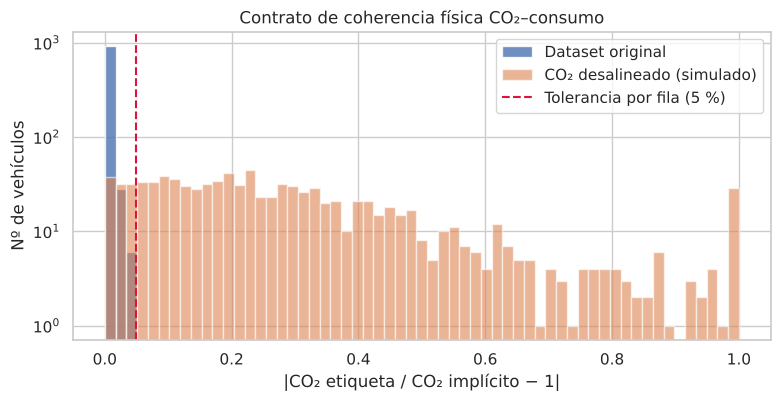

DataValidationError → Coherencia CO₂ ≈ k / mpg (fila a fila) error mediano=23.62%, filas con error ≤ 5%: 10.6%


In [6]:
from vehicle_emissions.validation import DataValidationError

corrupted = df.copy()
corrupted["Comb CO2"] = corrupted["Comb CO2"].sample(frac=1, random_state=0).to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 60)
ax.hist(co2_relative_error(df).clip(upper=1), bins=bins, alpha=0.8, label="Dataset original")
ax.hist(co2_relative_error(corrupted).clip(upper=1), bins=bins, alpha=0.6, label="CO₂ desalineado (simulado)")
ax.axvline(0.05, color="crimson", ls="--", label="Tolerancia por fila (5 %)")
ax.set(yscale="log", xlabel="|CO₂ etiqueta / CO₂ implícito − 1|", ylabel="Nº de vehículos",
       title="Contrato de coherencia física CO₂–consumo")
ax.legend()
fig.savefig("../reports/figures/01_contrato_co2.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    validate_fe_guide(corrupted)
except DataValidationError as e:
    print("DataValidationError →", str(e).splitlines()[-1])

## 4. Análisis exploratorio

### 4.1 Variables cuantitativas

In [7]:
cuantitativas = ["Eng Displ", "# Cyl", "# Gears", "City FE (Guide)", "Hwy FE (Guide)", "Comb FE (Guide)",
                 "Comb Unadj FE", "FE Rating", "Comb CO2"]
q = df[cuantitativas].astype(float)
pd.DataFrame({
    "media": q.mean(), "mediana": q.median(), "desv. típica": q.std(),
    "P5": q.quantile(.05), "P25": q.quantile(.25), "P75": q.quantile(.75), "P95": q.quantile(.95),
    "mín": q.min(), "máx": q.max(), "asimetría": q.skew(),
}).round(2)

,media,mediana,desv. típica,P5,P25,P75,P95,mín,máx,asimetría
Eng Displ,3.05,3.00,1.24,1.60,2.00,3.60,5.70,1.20,8.00,1.14
# Cyl,5.47,6.00,1.78,4.00,4.00,6.00,8.00,3.00,16.00,1.21
# Gears,7.75,8.00,1.96,1.60,7.00,9.00,10.00,1.00,10.00,-1.88
City FE (Guide),21.04,20.00,6.89,14.00,17.00,23.00,35.00,8.00,57.00,1.97
Hwy FE (Guide),26.96,26.00,6.59,18.00,22.00,31.00,38.00,11.00,58.00,0.87
Comb FE (Guide),23.26,22.00,6.63,15.15,19.00,26.00,35.00,9.00,57.00,1.50
Comb Unadj FE,31.19,29.08,9.59,20.03,24.86,35.46,48.79,11.24,80.47,1.56
FE Rating,4.57,5.00,1.28,2.15,4.00,5.00,7.00,1.00,8.00,0.10
Comb CO2,409.69,408.00,102.85,254.00,335.75,472.00,573.00,155.00,979.00,0.34


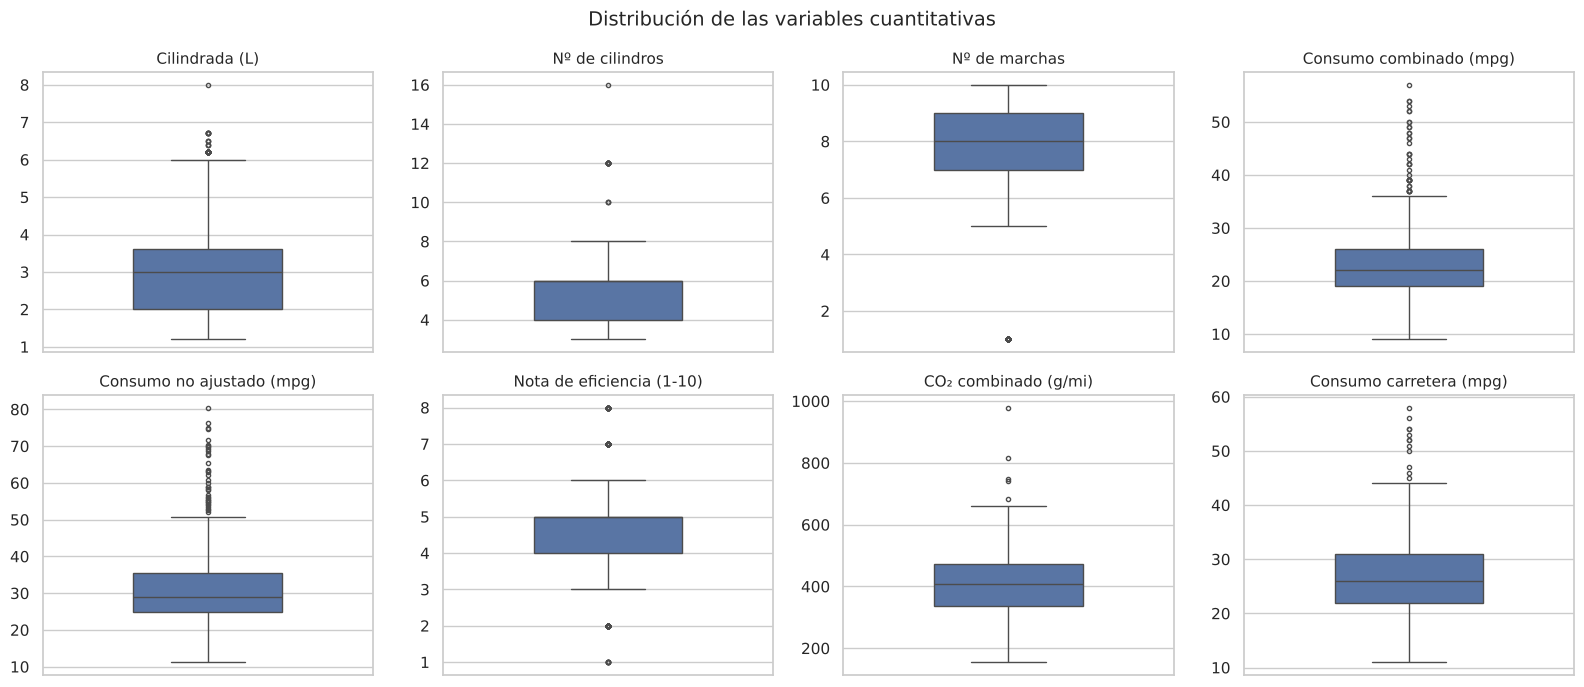

In [8]:
titulos = {
    "Eng Displ": "Cilindrada (L)", "# Cyl": "Nº de cilindros", "# Gears": "Nº de marchas",
    "Comb FE (Guide)": "Consumo combinado (mpg)", "Comb Unadj FE": "Consumo no ajustado (mpg)",
    "FE Rating": "Nota de eficiencia (1-10)", "Comb CO2": "CO₂ combinado (g/mi)", "Hwy FE (Guide)": "Consumo carretera (mpg)",
}
fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, t) in zip(axs.ravel(), titulos.items()):
    sns.boxplot(y=q[col], ax=ax, color="#4C72B0", width=0.45, fliersize=3)
    ax.set_title(t, fontsize=11); ax.set_ylabel("")
fig.suptitle("Distribución de las variables cuantitativas", fontsize=14)
fig.tight_layout()
fig.savefig("../reports/figures/01_boxplots_cuantitativas.png", dpi=150, bbox_inches="tight")
plt.show()

El consumo tiene asimetría positiva: la cola superior son **híbridos completos** (hasta 57 mpg) y la inferior,
deportivos de 10-16 cilindros. Ambos extremos son vehículos reales, no errores de captura, y se conservan.

### 4.2 Variables cualitativas

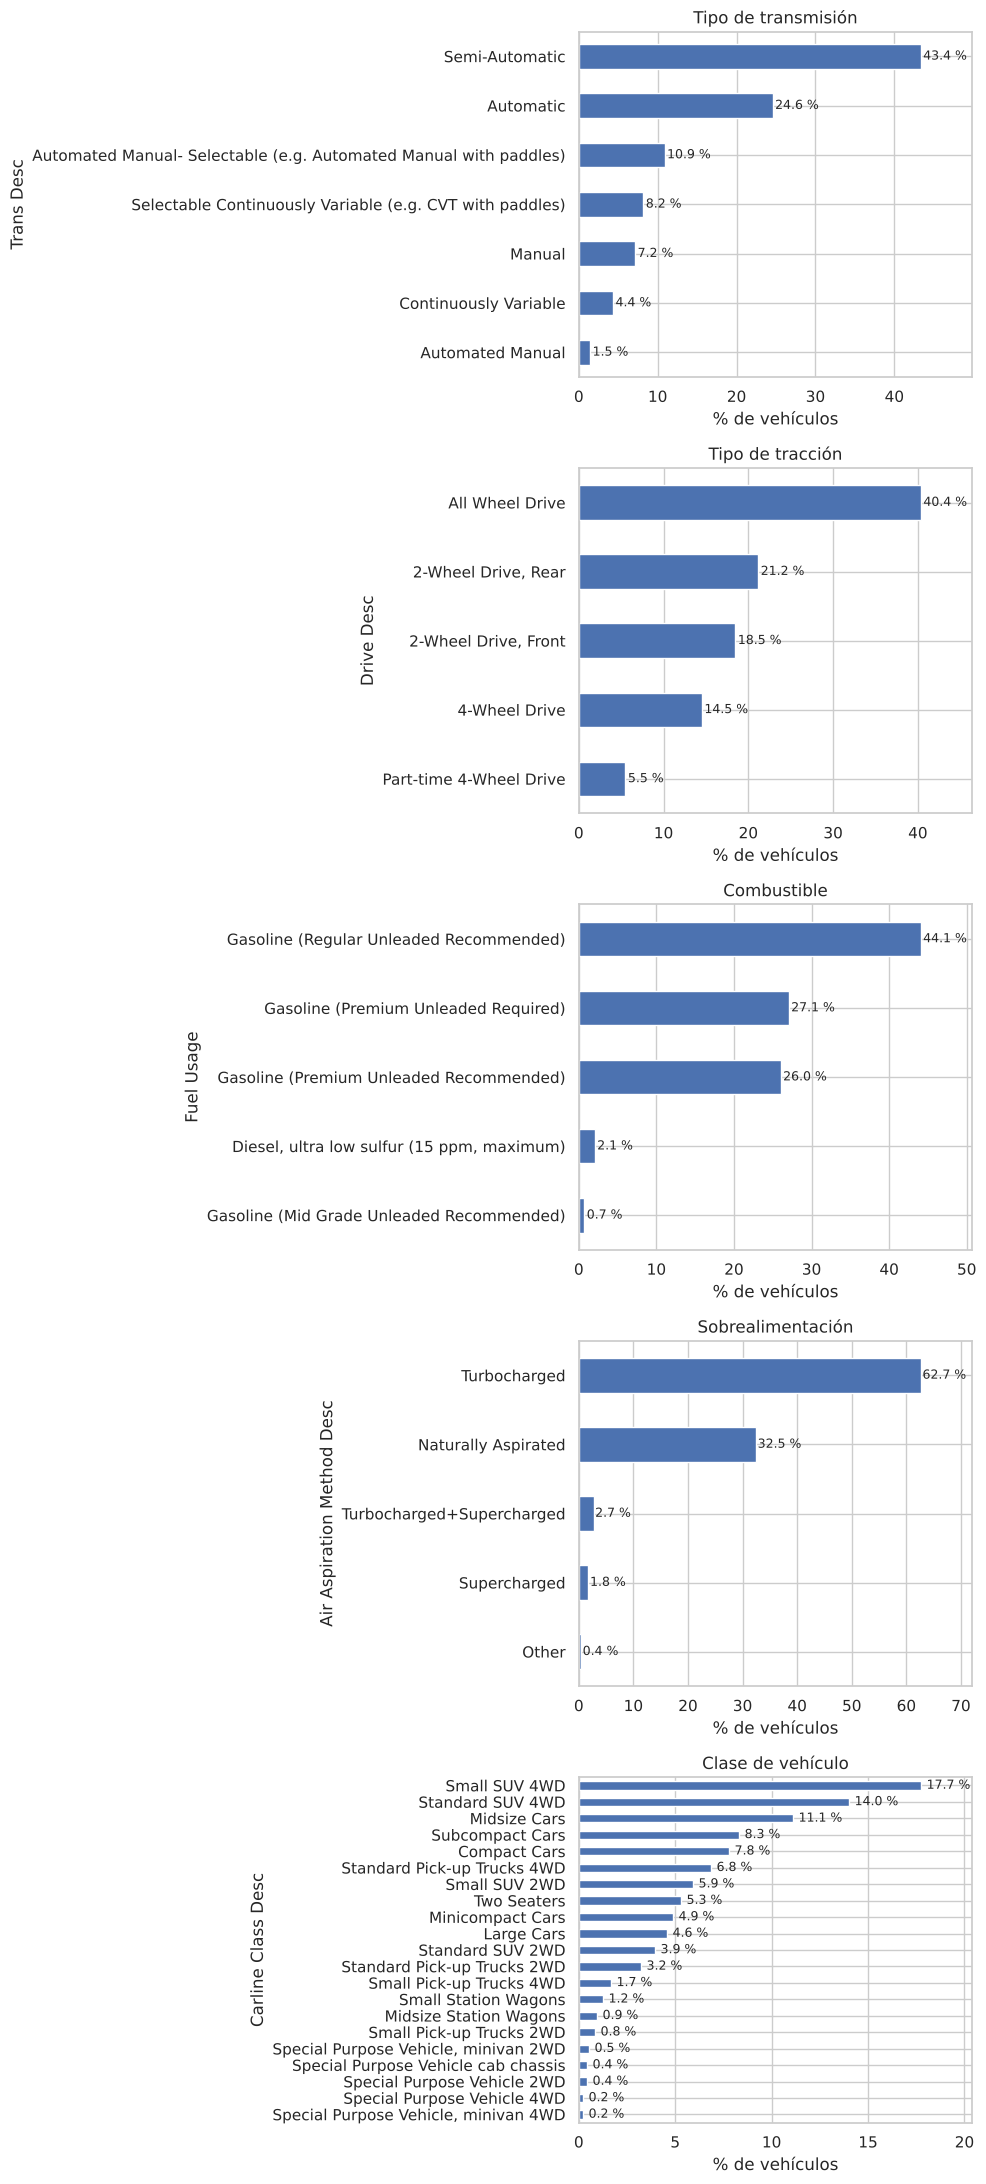

In [9]:
categoricas = {
    "Trans Desc": "Tipo de transmisión", "Drive Desc": "Tipo de tracción", "Fuel Usage": "Combustible",
    "Air Aspiration Method Desc": "Sobrealimentación", "Carline Class Desc": "Clase de vehículo",
}
fig, axs = plt.subplots(len(categoricas), 1, figsize=(10, 22))
for ax, (col, t) in zip(axs, categoricas.items()):
    pct = df[col].value_counts(normalize=True).sort_values() * 100
    pct.plot.barh(ax=ax, color="#4C72B0")
    for i, v in enumerate(pct):
        ax.text(v + 0.3, i, f"{v:.1f} %", va="center", fontsize=9)
    ax.set_title(t); ax.set_xlabel("% de vehículos"); ax.set_xlim(0, pct.max() * 1.15)
fig.tight_layout()
fig.savefig("../reports/figures/01_distribucion_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
indicadores = {"Hybrid": "Híbrido completo", "Mild Hybrid": "Mild hybrid", "Guzzler?": "Sujeto a gas guzzler",
               "Gas Guzzler Exempt": "Exento de gas guzzler", "Cyl Deact?": "Desactivación de cilindros",
               "Stop/Start": "Stop/Start", "Automatic": "Transmisión automática", "AWD/4WD": "Tracción total / 4x4",
               "Large": "Vehículo grande"}
(df[list(indicadores)].mean().rename(indicadores) * 100).round(1).to_frame("% de vehículos")

,% de vehículos
Híbrido completo,6.6
Mild hybrid,14.0
Sujeto a gas guzzler,5.7
Exento de gas guzzler,55.7
Desactivación de cilindros,18.9
Stop/Start,77.9
Transmisión automática,92.8
Tracción total / 4x4,60.4
Vehículo grande,48.9


Dos desequilibrios condicionan el modelado: sólo hay **20 diésel** (2,1 %) y **55 gas guzzlers** (5,7 %).
El primero limita lo que el modelo puede aprender del combustible; el segundo obliga a usar métricas
y particiones adecuadas a clases desequilibradas en el notebook 03.

### 4.3 Correlaciones

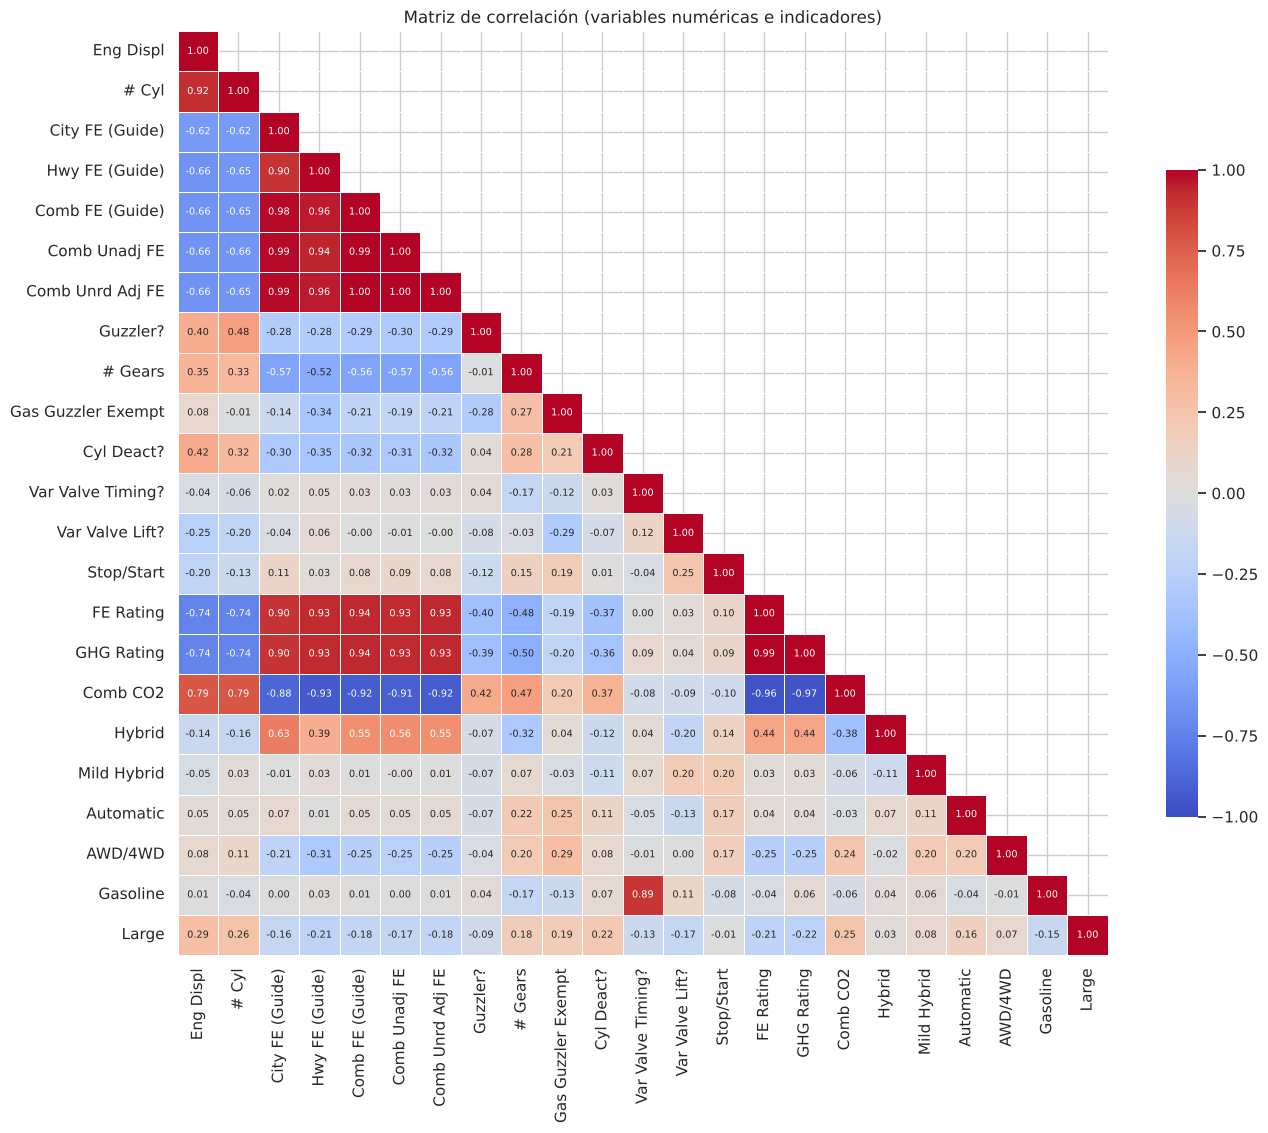

In [11]:
from vehicle_emissions.evaluation import plot_correlation, top_correlations

num = df.select_dtypes("number").astype(float)
corr = plot_correlation(num, title="Matriz de correlación (variables numéricas e indicadores)",
                        figsize=(15, 12), save_as="01_correlacion_completa.png")
plt.show()

In [12]:
top_correlations(corr, n=10)

,Más positivas,Más negativas
0,Comb FE (Guide) ↔ Comb Unrd Adj FE: 0.999,GHG Rating ↔ Comb CO2: -0.966
1,Comb Unadj FE ↔ Comb Unrd Adj FE: 0.995,FE Rating ↔ Comb CO2: -0.961
2,FE Rating ↔ GHG Rating: 0.995,Hwy FE (Guide) ↔ Comb CO2: -0.934
3,Comb FE (Guide) ↔ Comb Unadj FE: 0.994,Comb Unrd Adj FE ↔ Comb CO2: -0.925
4,City FE (Guide) ↔ Comb Unadj FE: 0.989,Comb FE (Guide) ↔ Comb CO2: -0.924
5,City FE (Guide) ↔ Comb Unrd Adj FE: 0.986,Comb Unadj FE ↔ Comb CO2: -0.914
6,City FE (Guide) ↔ Comb FE (Guide): 0.985,City FE (Guide) ↔ Comb CO2: -0.881
7,Hwy FE (Guide) ↔ Comb FE (Guide): 0.960,Eng Displ ↔ FE Rating: -0.741
8,Hwy FE (Guide) ↔ Comb Unrd Adj FE: 0.959,# Cyl ↔ GHG Rating: -0.740
9,Hwy FE (Guide) ↔ Comb Unadj FE: 0.942,Eng Displ ↔ GHG Rating: -0.739


**Control de fuga de información (*leakage*).** Las variables de consumo derivadas (ciudad, carretera, no ajustado,
notas de la etiqueta, CO₂, gas guzzler) se calculan a partir del propio consumo y correlacionan con él por encima de 0,9.
Quedan **excluidas como predictores**: sólo se modela con características técnicas conocidas antes del ensayo.

In [13]:
DERIVADAS = ["Comb Unrd Adj FE", "Comb Unadj FE", "City FE (Guide)", "Hwy FE (Guide)", "GHG Rating",
             "FE Rating", "Comb CO2", "Guzzler?"]
r = corr["Comb FE (Guide)"].drop("Comb FE (Guide)")
pd.DataFrame({"r con Comb FE": r.round(3),
              "Uso": np.where(r.index.isin(DERIVADAS), "excluida (derivada del objetivo)", "candidata")}
             ).sort_values("r con Comb FE", key=abs, ascending=False)

,r con Comb FE,Uso
Comb Unrd Adj FE,0.999,excluida (derivada del objetivo)
Comb Unadj FE,0.994,excluida (derivada del objetivo)
City FE (Guide),0.985,excluida (derivada del objetivo)
Hwy FE (Guide),0.960,excluida (derivada del objetivo)
GHG Rating,0.935,excluida (derivada del objetivo)
FE Rating,0.935,excluida (derivada del objetivo)
Comb CO2,-0.924,excluida (derivada del objetivo)
Eng Displ,-0.660,candidata
# Cyl,-0.655,candidata
# Gears,-0.563,candidata


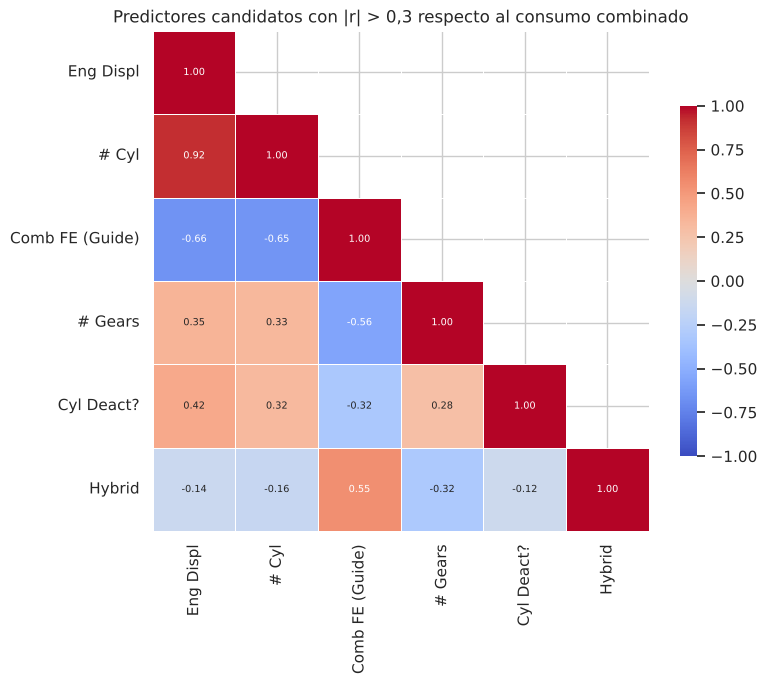

In [14]:
sel = [c for c in corr.index[corr["Comb FE (Guide)"].abs() > 0.3] if c not in DERIVADAS or c == "Comb FE (Guide)"]
plot_correlation(num[sel], title="Predictores candidatos con |r| > 0,3 respecto al consumo combinado",
                 figsize=(8, 6.5), save_as="01_correlacion_predictores.png")
plt.show()

`Eng Displ` y `# Cyl` están muy correlacionadas entre sí (r ≈ 0,92). Para modelos lineales esto encarece la
interpretación de coeficientes, aunque no afecta a la capacidad predictiva; para modelos de árboles es irrelevante.

### 4.4 Forma de la relación con el objetivo

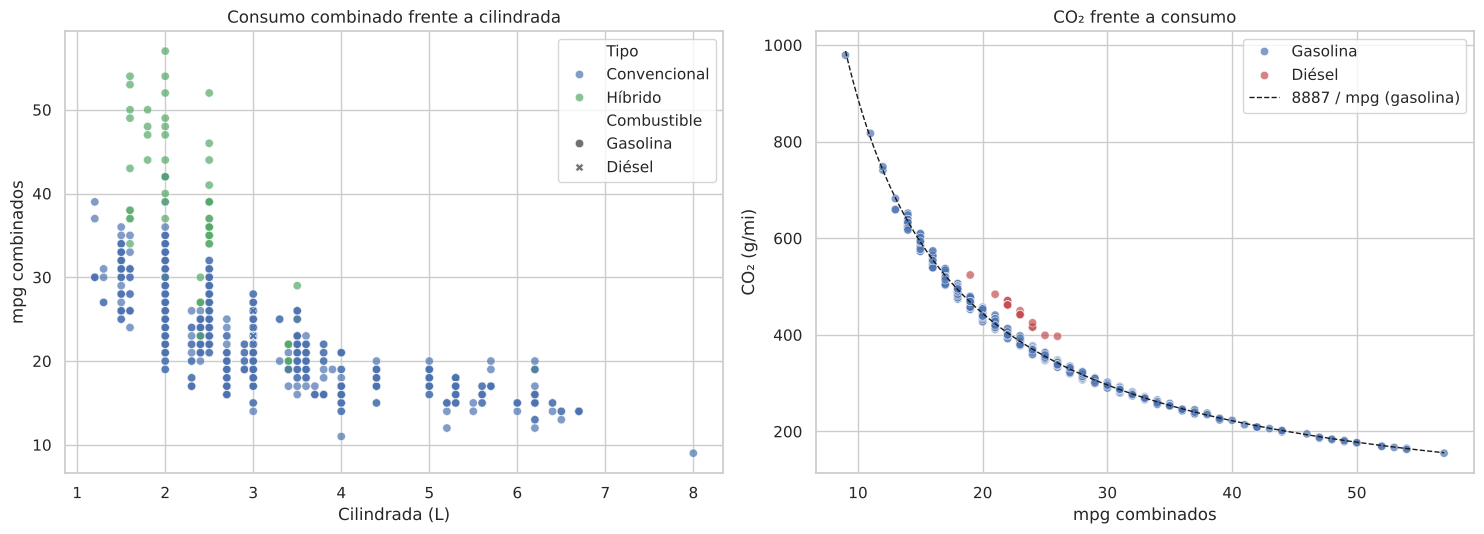

In [15]:
plot_df = df.assign(Tipo=df["Hybrid"].map({0: "Convencional", 1: "Híbrido"}),
                   Combustible=df["Gasoline"].map({0: "Diésel", 1: "Gasolina"}))
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=plot_df, x="Eng Displ", y="Comb FE (Guide)", hue="Tipo", style="Combustible",
                palette={"Convencional": "#4C72B0", "Híbrido": "#55A868"}, alpha=0.7, ax=axs[0])
axs[0].set(title="Consumo combinado frente a cilindrada", xlabel="Cilindrada (L)", ylabel="mpg combinados")
sns.scatterplot(data=plot_df, x="Comb FE (Guide)", y="Comb CO2", hue="Combustible",
                palette={"Diésel": "#C44E52", "Gasolina": "#4C72B0"}, alpha=0.7, ax=axs[1])
x = np.linspace(df["Comb FE (Guide)"].min(), df["Comb FE (Guide)"].max(), 200)
axs[1].plot(x, 8887 / x, "k--", lw=1, label="8887 / mpg (gasolina)")
axs[1].set(title="CO₂ frente a consumo", xlabel="mpg combinados", ylabel="CO₂ (g/mi)")
axs[1].legend()
fig.tight_layout()
fig.savefig("../reports/figures/01_cilindrada_consumo_co2.png", dpi=150, bbox_inches="tight")
plt.show()

* La relación cilindrada → mpg es **no lineal y heterocedástica**: a igual cilindrada, los híbridos se separan
  claramente. Anticipa que modelos no lineales y la variable `Hybrid` serán determinantes.
* CO₂ y mpg siguen una hipérbola exacta (los diésel por encima, por su mayor contenido en carbono por galón).
  Un modelo lineal debería ajustar mejor el CO₂ (proporcional a combustible por distancia) que los mpg.

### 4.5 Riesgo de fuga entre variantes de un mismo modelo

In [16]:
fam = df["Model Family"].value_counts()
print(f"{len(fam)} familias · {(fam > 1).sum()} con varias configuraciones · "
      f"{fam[fam > 1].sum()} filas ({fam[fam > 1].sum() / len(df):.0%}) pertenecen a familias repetidas")
fam.head(8).to_frame("nº configuraciones")

596 familias · 219 con varias configuraciones · 587 filas (61%) pertenecen a familias repetidas


,nº configuraciones
Model Family,
CHEVROLET | SILVERADO,16
GMC | SIERRA,15
TOYOTA | TUNDRA,11
CHEVROLET | SILVERADO MUD TERRAIN TIRES,9
HONDA | CIVIC 5DR,7
GMC | SIERRA MUD TERRAIN TIRES,7
CHEVROLET | TAHOE,7
CHEVROLET | CAMARO,6


Muchas configuraciones son variantes casi idénticas de un mismo modelo. Con una partición aleatoria, el modelo puede
"ver" en entrenamiento la variante gemela del vehículo de prueba. Por eso, además de la validación cruzada aleatoria,
los notebooks de modelado reportan una **validación cruzada agrupada por familia** (`GroupKFold`), que estima el
rendimiento sobre modelos de vehículo no vistos.

## 5. Exportación

In [17]:
out = PROCESSED_DIR / "fe_guide_2024_clean.csv"
df.to_csv(out, index=False)
print(f"Guardado data/processed/{out.name}: {df.shape[0]} filas × {df.shape[1]} columnas (validado)")

Guardado data/processed/fe_guide_2024_clean.csv: 964 filas × 32 columnas (validado)
